In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Load data
df = pd.read_csv('waca_dataset.csv')
TARGET = df['target_channel'].iloc[0]

feature_cols = [c for c in df.columns
                if c.endswith(('_mean','_std','_max','_min'))
                and TARGET not in c]
X = df[feature_cols]
y = df['target_busy']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Train XGBoost — base_score=0.5 fixes shap compatibility issue
xgb_clf = XGBClassifier(n_estimators=100, random_state=42,
                         eval_metric='logloss', verbosity=0,
                         base_score=0.5)          # ← THIS IS THE FIX
xgb_clf.fit(X_train, y_train)

print(f"Target: {TARGET}")
print(f"Features: {len(feature_cols)}")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Classes in train: {sorted(y_train.unique())}")
print(f"Classes in test:  {sorted(y_test.unique())}")

Target: rssi_temporal_B_b
Features: 92
Train: 160 | Test: 40
Classes in train: [0, 1]
Classes in test:  [0, 1]


SHAP: Random Forest


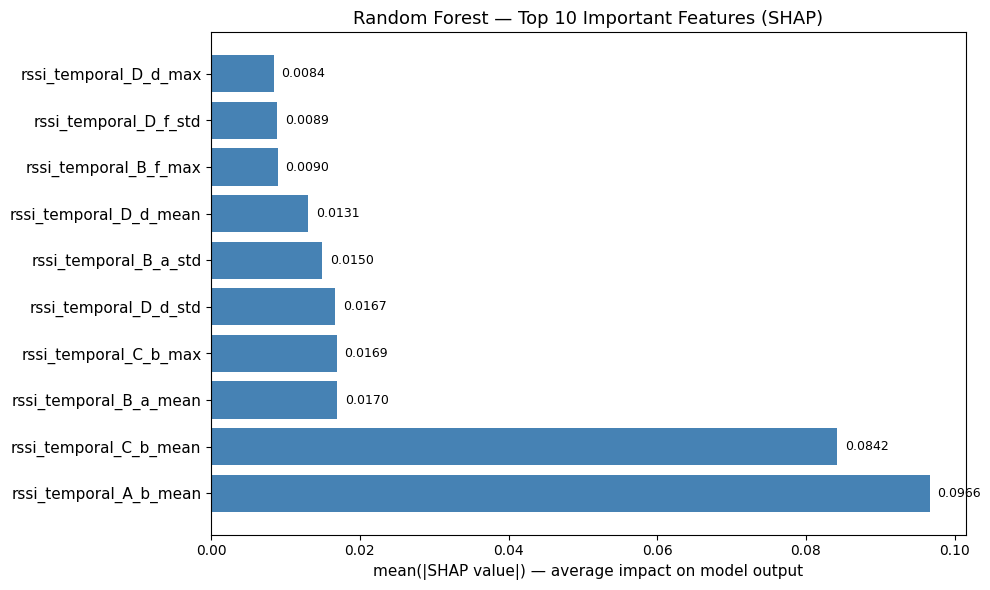


SHAP: XGBoost


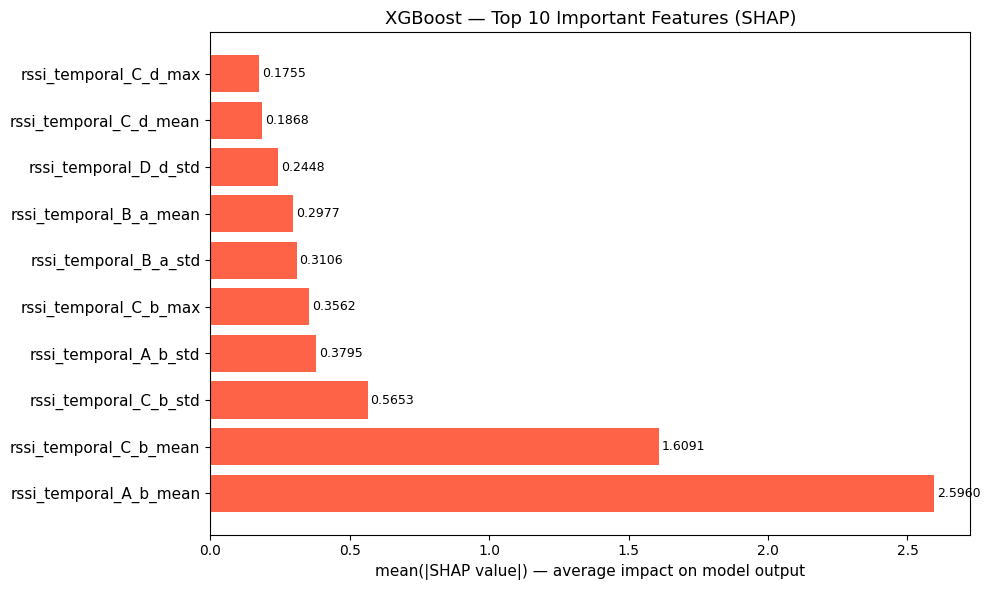

In [2]:
import xgboost as xgb
#SHAP: Random Forest
print("SHAP: Random Forest")
explainer_rf   = shap.TreeExplainer(rf_clf)
shap_values_rf = explainer_rf.shap_values(X_test)

# Handle both old and new shap versions
if isinstance(shap_values_rf, list):
    sv_rf = shap_values_rf[1]
else:
    # New shap: shape is (samples, features, classes)
    if shap_values_rf.ndim == 3:
        sv_rf = shap_values_rf[:, :, 1]
    else:
        sv_rf = shap_values_rf

# Calculate mean absolute SHAP manually
mean_shap_rf   = np.abs(sv_rf).mean(axis=0)
top10_idx_rf   = np.argsort(mean_shap_rf)[-10:]
top10_vals_rf  = mean_shap_rf[top10_idx_rf]
top10_names_rf = [feature_cols[i] for i in top10_idx_rf]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(range(10), top10_vals_rf, color='steelblue')
plt.yticks(range(10), top10_names_rf, fontsize=11)
plt.xlabel('mean(|SHAP value|) — average impact on model output', fontsize=11)
plt.title('Random Forest — Top 10 Important Features (SHAP)', fontsize=13)
plt.gca().invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, top10_vals_rf)):
    plt.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('shap_rf_summary.png', bbox_inches='tight', dpi=150)
plt.show()

#SHAP: XGBoost — using XGBoost built-in SHAP
print("\nSHAP: XGBoost")
dtest = xgb.DMatrix(X_test, feature_names=feature_cols)
shap_values_xgb = xgb_clf.get_booster().predict(dtest, pred_contribs=True)
shap_values_xgb = shap_values_xgb[:, :-1]  # remove bias column

mean_shap_xgb   = np.abs(shap_values_xgb).mean(axis=0)
top10_idx_xgb   = np.argsort(mean_shap_xgb)[-10:]
top10_vals_xgb  = mean_shap_xgb[top10_idx_xgb]
top10_names_xgb = [feature_cols[i] for i in top10_idx_xgb]

plt.figure(figsize=(10, 6))
bars = plt.barh(range(10), top10_vals_xgb, color='tomato')
plt.yticks(range(10), top10_names_xgb, fontsize=11)
plt.xlabel('mean(|SHAP value|) — average impact on model output', fontsize=11)
plt.title('XGBoost — Top 10 Important Features (SHAP)', fontsize=13)
plt.gca().invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, top10_vals_xgb)):
    plt.text(val + 0.01, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('shap_xgb_summary.png', bbox_inches='tight', dpi=150)
plt.show()


Explaining Idle sample — True label: 0


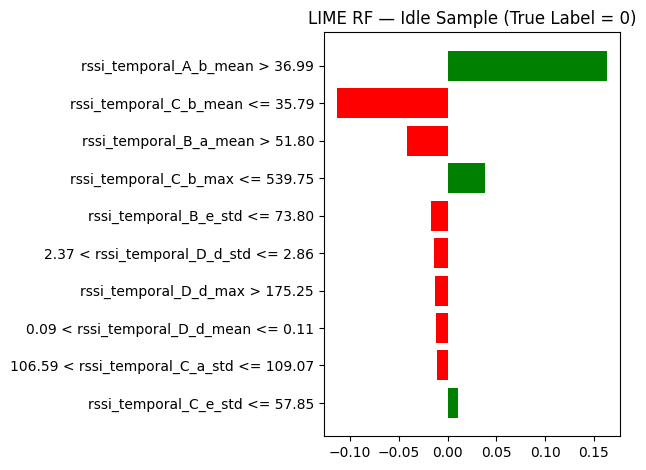

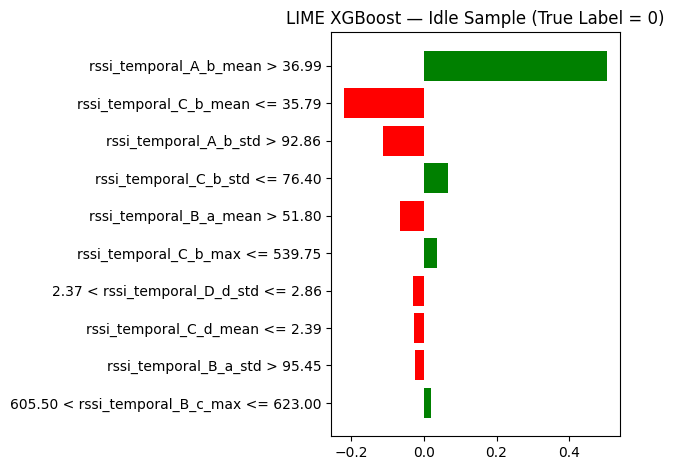


Explaining Busy sample — True label: 1


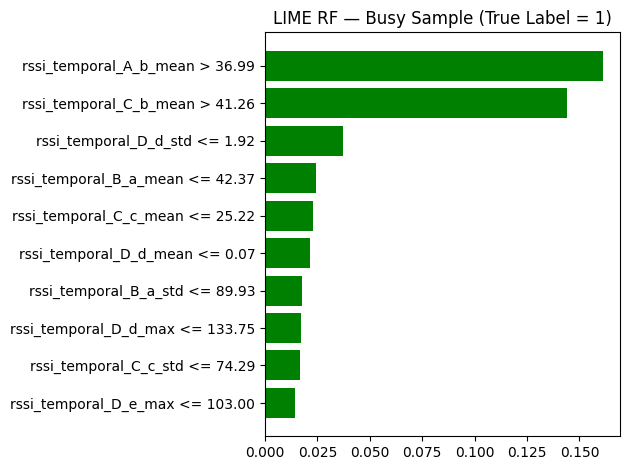

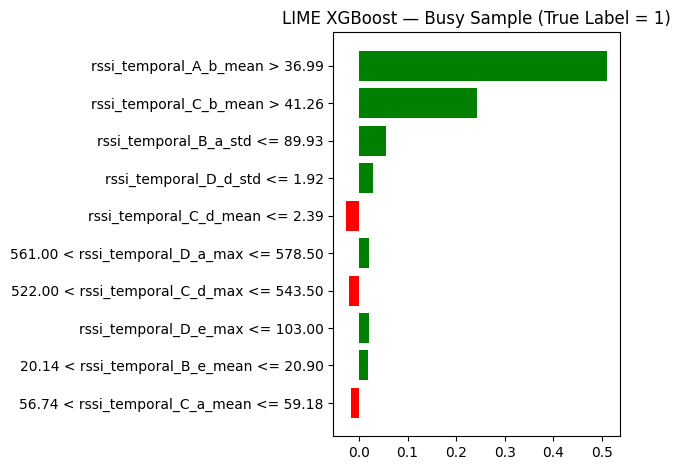

In [3]:
#LIME
import lime, lime.lime_tabular
lime_exp = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train.values,
    feature_names = feature_cols,
    class_names   = ['Idle', 'Busy'],
    mode          = 'classification',
    random_state  = 42)
# Find one Idle (0) and one Busy (1) from test set
test_labels = y_test.values
idle_pos = np.where(test_labels == 0)[0][0]   
busy_pos = np.where(test_labels == 1)[0][0]   

for label, pos in [('Idle', idle_pos), ('Busy', busy_pos)]:
    true_lbl = test_labels[pos]
    print(f"\nExplaining {label} sample — True label: {true_lbl}")

    # RF explanation
    exp_rf = lime_exp.explain_instance(
        X_test.values[pos], rf_clf.predict_proba, num_features=10)
    exp_rf.as_pyplot_figure()
    plt.title(f'LIME RF — {label} Sample (True Label = {true_lbl})')
    plt.tight_layout()
    plt.savefig(f'lime_rf_{label.lower()}.png', bbox_inches='tight')
    plt.show()

    # XGBoost explanation
    exp_xgb = lime_exp.explain_instance(
        X_test.values[pos], xgb_clf.predict_proba, num_features=10)
    exp_xgb.as_pyplot_figure()
    plt.title(f'LIME XGBoost — {label} Sample (True Label = {true_lbl})')
    plt.tight_layout()
    plt.savefig(f'lime_xgb_{label.lower()}.png', bbox_inches='tight')
    plt.show()